In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.linalg import lu_factor, lu_solve
from scipy.sparse.linalg import LinearOperator, lsqr
import scipy
import time
from scipy.interpolate import lagrange

from ader_dg_transport.ader_dg_2D import wave_ader_implicit_iter
from ader_dg_transport.ader_dg_2D import wave_ader_implicit_adjoint_iter

from ader_dg_transport.ader_dg_2D import wave_ader_implicit
from ader_dg_transport.ader_dg_2D import wave_ader_implicit_adjoint

import importlib
import os
os.environ["OMP_NUM_THREADS"] = "4"

In [2]:
xlim = 10.0
ylim = 10.0
nx = 10
ny = 10
poly_order = 3
c = 1.0
tend = 10

cfl = 0.1
dt = cfl * (xlim / nx)
nsteps = int(tend / dt) + 1
dt = tend / nsteps



In [3]:
# Todo:
# - iterable solver
# - variable c
# - free surface boundaries

# Reconstruct wave speed $c$from final state

Locator attempting to generate 1001 ticks ([0.0, ..., 1.0]), which exceeds Locator.MAXTICKS (1000).


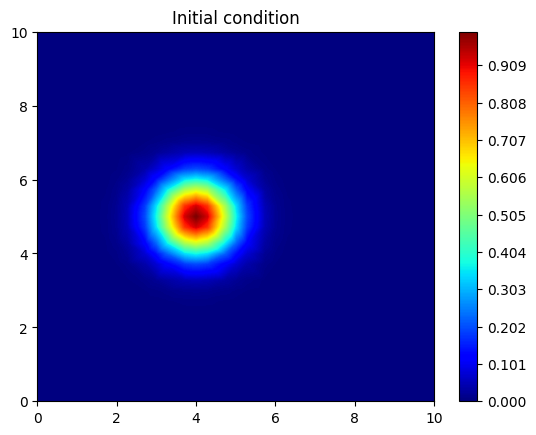

In [4]:
importlib.reload(wave_ader_implicit_iter)
importlib.reload(wave_ader_implicit_adjoint_iter)


forward_solver = wave_ader_implicit_iter.WaveAderDG2DImplicitIter(xlim, ylim, nx, ny, poly_order=poly_order, c=c, dt=dt, a=0.5)
adjoint_solver = wave_ader_implicit_adjoint_iter.WaveAderDG2DImplicitAdjointIter(xlim, ylim, nx, ny, poly_order=poly_order, c=c, dt=dt, a=forward_solver.a)

xs = forward_solver.xs[:, :, 0]
ys = forward_solver.ys[:, :, 0]
h0 = np.exp(-(xs - 4)**2 -(ys - 5)**2)

forward_solver.c[forward_solver.xs > 5] = 0.5
# forward_solver.c += 0.5 * (1 + np.sin(2 * np.pi * forward_solver.xs / xlim))
adjoint_solver.c[:] = forward_solver.c

plt.title(f'Initial condition')
plt.tricontourf(xs.ravel(), ys.ravel(), h0.ravel(), levels=1000, cmap='jet')
plt.colorbar()

CPU times: user 1.58 s, sys: 75.1 ms, total: 1.66 s
Wall time: 1.48 s


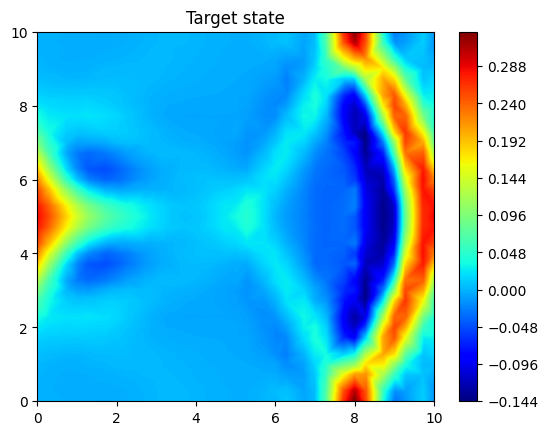

In [5]:
%%time 
xs = forward_solver.xs[:, :, 0]
ys = forward_solver.ys[:, :, 0]

forward_solver.u[:] = h0
forward_solver.v[:] = 0.0
forward_solver.h[:] = h0

target_ic = np.copy(forward_solver.state)

for _ in range(nsteps):
    forward_solver.time_step(verbose=False, maxiter=100, tol=3e-8, inner_maxiter=5)

target_state = np.copy(forward_solver.state)

plt.title(f'Target state')
plt.tricontourf(xs.ravel(), ys.ravel(), forward_solver.h.ravel(), levels=1000, cmap='jet')
plt.colorbar()

CPU times: user 830 ms, sys: 53.3 ms, total: 883 ms
Wall time: 757 ms


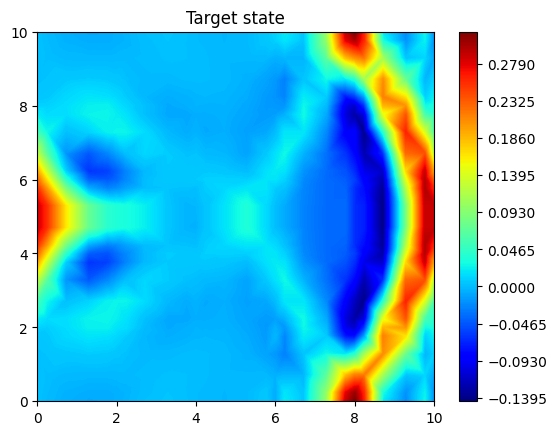

In [4]:
%%time 
xs = forward_solver.xs[:, :, 0]
ys = forward_solver.ys[:, :, 0]

forward_solver.u[:] = h0
forward_solver.v[:] = 0.0
forward_solver.h[:] = h0

target_ic = np.copy(forward_solver.state)

for _ in range(nsteps):
    forward_solver.time_step(verbose=False, maxiter=100, tol=3e-8, inner_maxiter=5)

target_state = np.copy(forward_solver.state)

plt.title(f'Target state')
plt.tricontourf(xs.ravel(), ys.ravel(), forward_solver.h.ravel(), levels=1000, cmap='jet')
plt.colorbar()

## Reconstruct from final state

In [6]:
reconstructed_ic = np.ones_like(target_state)

# calculate initial error
forward_solver.state[:] = reconstructed_ic
for _ in range(nsteps):
    forward_solver.time_step(verbose=False, maxiter=100, tol=3e-8, inner_maxiter=5)

error = forward_solver.state - target_state

print(forward_solver.norm(*forward_solver.get_vars(error**2)))

# iterate
for _ in range(5):
    
    adjoint_solver.state[:] = error
    for _ in range(nsteps):
        adjoint_solver.time_step(verbose=False, maxiter=100, tol=3e-8, inner_maxiter=5)

    # reconstructed_ic -= adjoint_solver.state

    # forward_solver.state[:] = reconstructed_ic
    # for _ in range(nsteps):
    #     forward_solver.time_step(verbose=False, maxiter=100, tol=1e-6, inner_maxiter=5)
    
    # error = forward_solver.state - target_state
    
    # print(forward_solver.norm(*forward_solver.get_vars(error**2)))
    break

17.15269227153574


### gradient check

In [7]:
du0 = np.random.random(forward_solver.state.shape)
forward_solver.state[:] = du0
for _ in range(nsteps):
    forward_solver.time_step(verbose=False, maxiter=50, tol=1e-6, inner_maxiter=5)

du1 = np.copy(forward_solver.state)

forward_solver.u[:] = h0
forward_solver.v[:] = 0.0
forward_solver.h[:] = h0
forward_solver.state[:] += du0
for _ in range(nsteps):
    forward_solver.time_step(verbose=False, maxiter=50, tol=1e-6, inner_maxiter=5)

u1 = np.copy(forward_solver.state)

# sanity check
print(np.allclose(target_state + du1, u1))

True


In [8]:
reconstructed_ic = np.ones_like(target_state)

# calculate initial error
forward_solver.state[:] = reconstructed_ic
for i in range(nsteps):
    forward_solver.time_step(verbose=False, maxiter=100, tol=1e-6, inner_maxiter=5)

error0_ = forward_solver.state - target_state
error0 = 0.5*forward_solver.norm(*forward_solver.get_vars(error0_))**2

In [9]:
eps = 1e-3
reconstructed_ic = np.ones_like(target_state) + eps * du0

# calculate initial error
forward_solver.state[:] = reconstructed_ic
for i in range(nsteps):
    forward_solver.time_step(verbose=False, maxiter=100, tol=1e-6, inner_maxiter=5)

error1_ = forward_solver.state - target_state
error1 = 0.5*forward_solver.norm(*forward_solver.get_vars(error1_))**2

In [10]:
print(error1 - error0)
print((forward_solver.weights_2D[None, None, None] * error0_ * eps * du1).sum() * 0.25 * adjoint_solver.dx * adjoint_solver.dy)

0.1494047549082893
0.14936152420742455


In [11]:
print((forward_solver.weights_2D[None, None, None] * adjoint_solver.state * eps * du0).sum() * 0.25 * adjoint_solver.dx * adjoint_solver.dy)

0.1493615242074246


# Vary c

In [12]:
W = adjoint_solver.weights_2D[None, None, None] * adjoint_solver.dy * adjoint_solver.dx * 0.25
M = adjoint_solver.weights_2D[None, None] * adjoint_solver.dy * adjoint_solver.dx * 0.25

W_half = np.sqrt(W)
M_half = np.sqrt(M)

W_half_inv = 1 / W_half
M_half_inv = 1 / M_half

In [13]:
history_array = np.zeros((nsteps,) + forward_solver.state_pred.shape)

In [34]:
def get_error(c_in, target_state, ic_state, fill_gradient=False):
    forward_solver.state[:] = ic_state
    forward_solver.c[:] = c_in[:, :, None]
    adjoint_solver.c[:] = forward_solver.c
    for i in range(nsteps):
        forward_solver.time_step(verbose=False, maxiter=100, tol=3e-8, inner_maxiter=5)
        if fill_gradient:
            history_array[i] = forward_solver.wave_forward(forward_solver.state_pred, forward_solver.state_pred) / forward_solver.c[:, :, None]
    
    error = forward_solver.state - target_state

    return error

In [15]:
def G_matvec(dc_vec):
    # 1) reshape u0

    n = forward_solver.poly_order + 1

    # dc = dc_vec.reshape((nx, ny, 1, 1, n, n)) * M_half_inv
    dc = dc_vec.reshape((nx, ny, n, n)) * M_half_inv
    dc = dc.reshape((nx, ny, 1, 1, n, n))
    forward_solver.state[:] = 0.0
    for i in range(nsteps):
        rhs = forward_solver.get_rhs(forward_solver.state)
        rhs += -history_array[i] * dc
        forward_solver.time_step(verbose=False, maxiter=100, tol=3e-8, inner_maxiter=5, rhs_in=rhs)

    return np.copy(forward_solver.state * W * W_half_inv).ravel()


def G_rmatvec(y_vec):
    # y_vec has size m = Nrec*Nt
    data = y_vec.reshape(adjoint_solver.state.shape) * W_half_inv

    adjoint_solver.state[:] = data

    n = forward_solver.poly_order + 1
    out = np.zeros((nx, ny, n, n))
    weights = adjoint_solver.weights_x[None, None, None, :, None, None]
    
    for i in range(nsteps):
        
        adjoint_solver.time_step(verbose=False, maxiter=100, tol=3e-8, inner_maxiter=5)
        out += -(adjoint_solver.state_pred[:, :, :, ::-1] * history_array[nsteps - i - 1] * weights).sum(axis=(2, 3))

    return (out * M * M_half_inv).ravel()

## Test gradient

In [16]:
def final_norm(arr):
    return 

In [46]:
c0 = np.ones_like(forward_solver.c[:, :, 0])
c0[xs > 5] = 0.75
error = get_error(c0, target_state, target_ic, fill_gradient=True)

In [47]:
eps = 1e-5
dc = np.random.random(c0.shape) * eps

In [48]:
error0 = get_error(c0 - 0.5 * dc, target_state, target_ic)
error1 = get_error(c0 + 0.5 * dc, target_state, target_ic)

In [49]:
# check linear gradient
derror = (error1 - error) - (error0 - error)
forward_solver.c[:] = c0[:, :, None]
de = G_matvec(M_half * dc)
print('Ctr diff:', (forward_solver.weights_2D[None, None, None] * derror * derror).sum() * 0.25 * adjoint_solver.dx * adjoint_solver.dy)
print('Gradient:', (de * de).sum())

Ctr diff: 1.3161241150699554e-08
Gradient: 1.3161241164281853e-08


In [50]:
print('Cntr and exact gradient rel diff:', np.linalg.norm(de.reshape(derror.shape) * W_half_inv - derror) / np.linalg.norm(derror))

Cntr and exact gradient rel diff: 6.235103898546953e-10


In [51]:
print(0.5*forward_solver.norm(*forward_solver.get_vars(error1))**2 - 0.5*forward_solver.norm(*forward_solver.get_vars(error0))**2)
print((forward_solver.weights_2D[None, None, None] * error * derror).sum() * 0.25 * adjoint_solver.dx * adjoint_solver.dy)

-7.667843944458852e-06
-7.667843938008581e-06


In [52]:
print((error * de.reshape(derror.shape) * W_half).sum())

-7.667843946620141e-06


In [53]:
adjoint_solver.c[:] = c0[:, :, None]
dedc = G_rmatvec(error * W_half).reshape(c0.shape) * M_half
print((dedc.ravel() * dc.ravel()).sum())

-7.667843946620128e-06


## Test adjoint

In [54]:
v1 = np.zeros(c0.size)
v2 = np.zeros(adjoint_solver.state.size)

i = 10
j = 27

v1[i] = 1
v2[j] = 1

forward_solver.c[:] = c0[:, :, None]
adjoint_solver.c[:] = forward_solver.c

out1 = G_matvec(v1)
out2 = G_rmatvec(v2)

In [55]:
# need to do DG inner product here - should fix this
print((out1 * v2).sum())
print((out2 * v1).sum())

-0.01175604408888948
-0.011756044088889488


## Test solving with Newton method-ish

- $||G \;\delta\boldsymbol{ c}||_2^2 \approx ||\delta e||^2_w$
- And $G$ and $G^T$ are implemented correctly

In [27]:
dc = np.random.random(c0.shape)

In [28]:
# c_exact = np.ones_like(xs)
# c_exact[xs > 5] = 0.5

c_exact = 1 + 0.01 * (np.sin(2 * np.pi * xs / xlim))

forward_solver.state[:] = target_ic
forward_solver.c[:] = c_exact[:, :, None]
for _ in range(nsteps):
    forward_solver.time_step(verbose=False, maxiter=300, tol=3e-8, inner_maxiter=5)

target_state = np.copy(forward_solver.state)

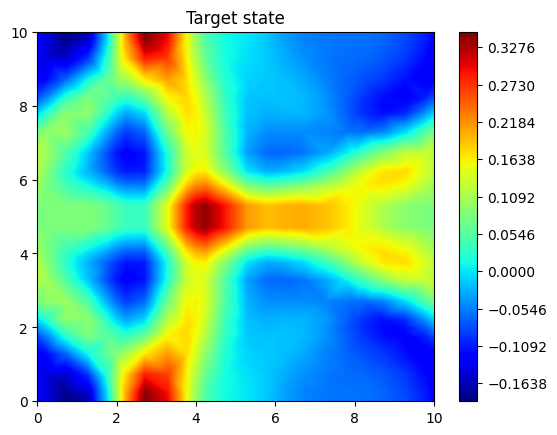

In [1069]:
plt.title(f'Target state')
plt.tricontourf(xs.ravel(), ys.ravel(), forward_solver.h.ravel(), levels=1000, cmap='jet')
plt.colorbar()

In [1072]:
# eps = 1e-1
# c0 = c_exact - eps * h0

c0 = np.ones_like(c_exact)

In [69]:
G = LinearOperator(
    shape=(target_state.size, c0.size),
    matvec=G_matvec,
    rmatvec=G_rmatvec,
    dtype=np.float64
)

In [65]:
def optimization_step(c_in, target_state, ic_state, maxiter=10):

    error = get_error(c_in, target_state, ic_state, fill_gradient=True)

    b = (-error * W_half).ravel()
    
    result = lsqr(G, b, atol=1e-10, btol=1e-10, iter_lim=maxiter)
    dc = result[0].reshape(c0.shape) * M_half_inv

    c_out = c_in + dc

    return c_out

In [1073]:
error = get_error(c0, target_state, target_ic, fill_gradient=True)
c_error = c0 - c_exact
print('Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25)

dedc = G_rmatvec(error * W_half).reshape(c0.shape) * M_half
print('||dedc||:', np.linalg.norm(dedc))


Final state error: 0.002415549861839572
Wave speed (c) error: 0.002499999999999999
||dedc||: 0.04539541011436849


In [1080]:
c_new = np.copy(c0)
for i in range(5):
    c_new = optimization_step(c_new, target_state, target_ic, maxiter=30)

    # get error in final state and wave speed
    error = get_error(c_new, target_state, target_ic, fill_gradient=True)
    c_error = c_new - c_exact
    
    print(f'Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2)
    print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25)

    # get gradient in c - check to see if we're heading towards a minimum
    dedc = G_rmatvec(error * W_half).reshape(c0.shape) * M_half

    print('||dedc||:', np.linalg.norm(dedc))
    print()


Final state error: 6.116805151338968e-06
Wave speed (c) error: 0.000238036648233934
||dedc||: 0.0018111192924452032

Final state error: 2.3684359452371168e-08
Wave speed (c) error: 1.3316805222811171e-05
||dedc||: 8.887129812363931e-05

Final state error: 2.2556176573149494e-09
Wave speed (c) error: 3.7085682226250507e-06
||dedc||: 4.898583737050767e-06

Final state error: 5.894665321537403e-10
Wave speed (c) error: 1.5321271522083857e-06
||dedc||: 1.7564755174664162e-06

Final state error: 2.391036151486869e-10
Wave speed (c) error: 8.970348933910004e-07
||dedc||: 1.0859922198740775e-06



In [1085]:
# plt.title(f'Final c error')
# plt.tricontourf(xs.ravel(), ys.ravel(), (c_new).ravel(), levels=1000, cmap='jet')
# plt.colorbar()

In [1082]:
for i in range(5):
    c_new = optimization_step(c_new, target_state, target_ic, maxiter=30)

    # get error in final state and wave speed
    error = get_error(c_new, target_state, target_ic, fill_gradient=True)
    c_error = c_new - c_exact
    
    print(f'Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2)
    print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25)

    # get gradient in c - check to see if we're heading towards a minimum
    dedc = G_rmatvec(error * W_half).reshape(c0.shape) * M_half

    print('||dedc||:', np.linalg.norm(dedc))
    print()
    

Final state error: 1.1796025086864806e-10
Wave speed (c) error: 5.398626072533424e-07
||dedc||: 7.153768357436502e-07

Final state error: 6.540531417027335e-11
Wave speed (c) error: 3.699723935527127e-07
||dedc||: 7.933423702570874e-07

Final state error: 3.9061442263935534e-11
Wave speed (c) error: 2.555697542307951e-07
||dedc||: 3.1562865449630044e-07

Final state error: 2.1318330237460082e-11
Wave speed (c) error: 1.6363979544564325e-07
||dedc||: 1.7228913575040466e-06

Final state error: 1.3052120081776145e-11
Wave speed (c) error: 1.304990924563934e-07
||dedc||: 1.5753977227006818e-07



In [1087]:
for i in range(5):
    c_new = optimization_step(c_new, target_state, target_ic, maxiter=50)

    # get error in final state and wave speed
    error = get_error(c_new, target_state, target_ic, fill_gradient=True)
    c_error = c_new - c_exact
    
    print(f'Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2)
    print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25)

    # get gradient in c - check to see if we're heading towards a minimum
    dedc = G_rmatvec(error * W_half).reshape(c0.shape) * M_half

    print('||dedc||:', np.linalg.norm(dedc))
    print()
    

Final state error: 1.9100213614572334e-12
Wave speed (c) error: 4.7854877480526626e-08
||dedc||: 6.23294042645159e-08

Final state error: 8.956122995482131e-13
Wave speed (c) error: 3.238944728153014e-08
||dedc||: 2.6078750679850198e-08

Final state error: 5.59745831424459e-13
Wave speed (c) error: 2.3020822242262396e-08
||dedc||: 1.3275098656676645e-08

Final state error: 3.8864603345189723e-13
Wave speed (c) error: 1.7703997756120084e-08
||dedc||: 1.275965213148632e-08

Final state error: 2.847727099386505e-13
Wave speed (c) error: 1.3545628927078657e-08
||dedc||: 1.0593830421357186e-08



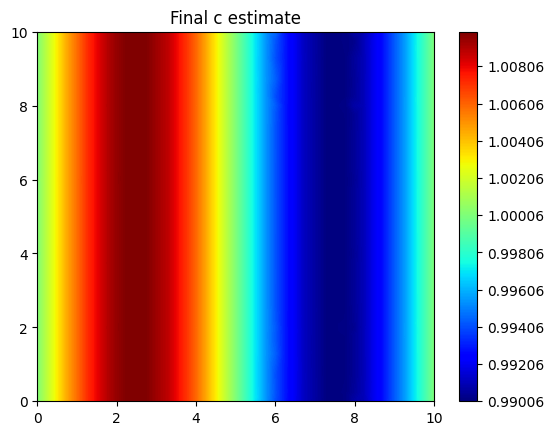

In [1088]:
plt.title(f'Final c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_new).ravel(), levels=1000, cmap='jet')
plt.colorbar()

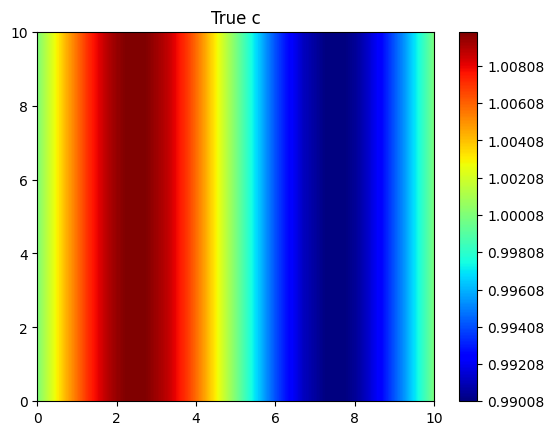

In [1086]:
plt.title(f'True c')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_exact).ravel(), levels=1000, cmap='jet')
plt.colorbar()

## Test with L-BFGS preconditioner

In [56]:
# c_exact = np.ones_like(xs)
# c_exact[xs > 5] = 0.5

c_exact = 1 + 0.1 * (np.sin(2 * np.pi * xs / xlim))

forward_solver.state[:] = target_ic
forward_solver.c[:] = c_exact[:, :, None]
for _ in range(nsteps):
    forward_solver.time_step(verbose=False, maxiter=300, tol=3e-8, inner_maxiter=5)

target_state = np.copy(forward_solver.state)

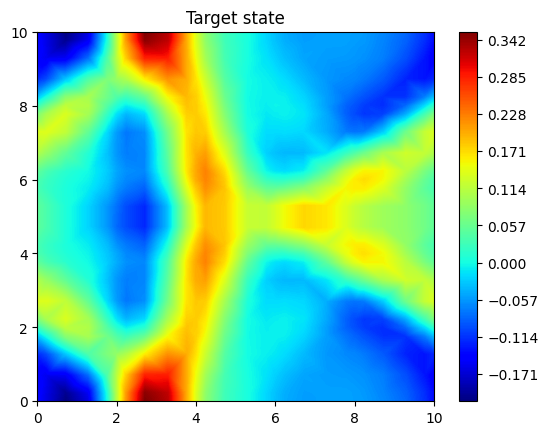

In [57]:
plt.title(f'Target state')
plt.tricontourf(xs.ravel(), ys.ravel(), forward_solver.h.ravel(), levels=1000, cmap='jet')
plt.colorbar()

In [58]:
# eps = 1e-1
# c0 = c_exact - eps * h0

c0 = np.ones_like(c_exact)

In [59]:
def cost_function(c_in):
    c_in = c_in.reshape(c0.shape)
    error = get_error(c_in, target_state, target_ic, fill_gradient=True)
    return 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2

In [60]:
def jac_function(c_in):
    c_in = c_in.reshape(c0.shape)
    error = get_error(c_in, target_state, target_ic, fill_gradient=True)

    dedc = G_rmatvec(error * W_half).reshape(c0.shape) * M_half

    return dedc.ravel()

In [61]:
error = get_error(c0, target_state, target_ic, fill_gradient=True)
c_error = c0 - c_exact
print('Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25)

dedc = G_rmatvec(error * W_half).reshape(c0.shape) * M_half
print('||dedc||:', np.linalg.norm(dedc))


Final state error: 0.22841138378262524
Wave speed (c) error: 0.25
||dedc||: 0.4804714772511363


In [62]:
%%time
result = scipy.optimize.minimize(cost_function, c0.ravel(), jac=jac_function, method='L-BFGS-B', options=dict(maxiter=30))

CPU times: user 1min 43s, sys: 33.8 s, total: 2min 17s
Wall time: 1min 23s


In [63]:
c_est = result.x.reshape(c0.shape)

error = get_error(c_est, target_state, target_ic, fill_gradient=True)
c_error = c_est - c_exact
print('Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25)

dedc = G_rmatvec(error * W_half).reshape(c0.shape) * M_half
print('||dedc||:', np.linalg.norm(dedc))


Final state error: 0.00012079482674844884
Wave speed (c) error: 0.02157269601260979
||dedc||: 0.0012574420178082142


In [67]:
c_new = np.copy(c_est)

In [70]:
for i in range(5):
    c_new = optimization_step(c_new, target_state, target_ic, maxiter=30)

    # get error in final state and wave speed
    error = get_error(c_new, target_state, target_ic, fill_gradient=True)
    c_error = c_new - c_exact
    
    print(f'Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2)
    print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25)

    # get gradient in c - check to see if we're heading towards a minimum
    dedc = G_rmatvec(error * W_half).reshape(c0.shape) * M_half

    print('||dedc||:', np.linalg.norm(dedc))
    print()

Final state error: 1.890114647923504e-05
Wave speed (c) error: 0.0036494418632143943
||dedc||: 0.006521795310384284

Final state error: 7.860483322412022e-07
Wave speed (c) error: 0.0014463696533569361
||dedc||: 0.0005557935929321609

Final state error: 2.47212377887862e-07
Wave speed (c) error: 0.0008723115360613813
||dedc||: 9.912852705454763e-05

Final state error: 1.233313495668816e-07
Wave speed (c) error: 0.0006044837014168854
||dedc||: 3.1453952523580605e-05

Final state error: 7.204906595276973e-08
Wave speed (c) error: 0.0004482659207668105
||dedc||: 2.8241214949378686e-05



In [73]:
for i in range(3):
    c_new = optimization_step(c_new, target_state, target_ic, maxiter=100)

    # get error in final state and wave speed
    error = get_error(c_new, target_state, target_ic, fill_gradient=True)
    c_error = c_new - c_exact
    
    print(f'Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2)
    print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25)

    # get gradient in c - check to see if we're heading towards a minimum
    dedc = G_rmatvec(error * W_half).reshape(c0.shape) * M_half

    print('||dedc||:', np.linalg.norm(dedc))
    print()
    

Final state error: 3.8728594148819695e-10
Wave speed (c) error: 1.2056826830071205e-05
||dedc||: 2.7761751767098534e-06



In [76]:
for i in range(3):
    c_new = optimization_step(c_new, target_state, target_ic, maxiter=200)

    # get error in final state and wave speed
    error = get_error(c_new, target_state, target_ic, fill_gradient=True)
    c_error = c_new - c_exact
    
    print(f'Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2)
    print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25)
    
    # get gradient in c - check to see if we're heading towards a minimum
    dedc = G_rmatvec(error * W_half).reshape(c0.shape) * M_half

    print('||dedc||:', np.linalg.norm(dedc))
    print()
    

Final state error: 4.6129431361066574e-11
Wave speed (c) error: 6.120244181121262e-07
||dedc||: 4.896225044295927e-06

Final state error: 1.0464508040009487e-12
Wave speed (c) error: 4.439441382284241e-08
||dedc||: 3.350691679084755e-07

Final state error: 1.4295475088597915e-13
Wave speed (c) error: 9.353288551319134e-09
||dedc||: 2.3226037361278393e-08



In [77]:
for i in range(2):
    c_new = optimization_step(c_new, target_state, target_ic, maxiter=400)

    # get error in final state and wave speed
    error = get_error(c_new, target_state, target_ic, fill_gradient=True)
    c_error = c_new - c_exact
    
    print(f'Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2)
    print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25)
    
    # get gradient in c - check to see if we're heading towards a minimum
    dedc = G_rmatvec(error * W_half).reshape(c0.shape) * M_half

    print('||dedc||:', np.linalg.norm(dedc))
    print()

Final state error: 4.354522588289545e-16
Wave speed (c) error: 3.027878201191928e-11
||dedc||: 8.531003643640845e-09

Final state error: 1.656857587531938e-18
Wave speed (c) error: 9.907148998500183e-14
||dedc||: 3.6355372207695806e-11



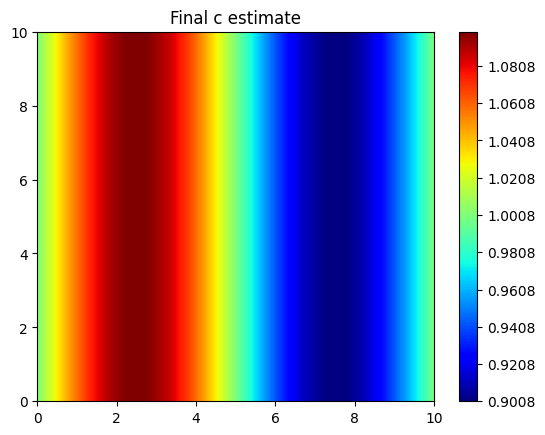

In [78]:
plt.title(f'Final c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_new).ravel(), levels=1000, cmap='jet')
plt.colorbar()